<h3 style="color:yellow">Importing Important Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings('ignore')

<h3 style="color:red">Load Dataset</h3>

In [2]:
calendar = pd.read_csv("calendar.csv")
sales = pd.read_csv("sales_train_validation.csv")
prices = pd.read_csv("sell_prices.csv")

In [3]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [4]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [5]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


<h3 style="color:yellow">Dataset Shape</h3>

In [6]:
print("Calendar Shape :", calendar.shape)
print("Sales Shape :", sales.shape)
print("Prices Shape :", prices.shape)

Calendar Shape : (1969, 14)
Sales Shape : (30490, 1919)
Prices Shape : (6841121, 4)


In [7]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [8]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [9]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [10]:
#Missing Values
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [11]:
sales.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

In [12]:
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [13]:
#Duplicate Values
print(calendar.duplicated().sum())
print(sales.duplicated().sum())
print(prices.duplicated().sum())

0
0
0


In [14]:
#Statastical Summary
calendar.describe(include='all')

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [15]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [16]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [17]:
#Convert Date
calendar['date'] = pd.to_datetime(calendar['date'])

In [18]:
#Data Types
calendar.dtypes

date            datetime64[ns]
wm_yr_wk                 int64
weekday                 object
wday                     int64
month                    int64
year                     int64
d                       object
event_name_1            object
event_type_1            object
event_name_2            object
event_type_2            object
snap_CA                  int64
snap_TX                  int64
snap_WI                  int64
dtype: object

<h2 style="color:yellow">Monthly Distribution</h2>

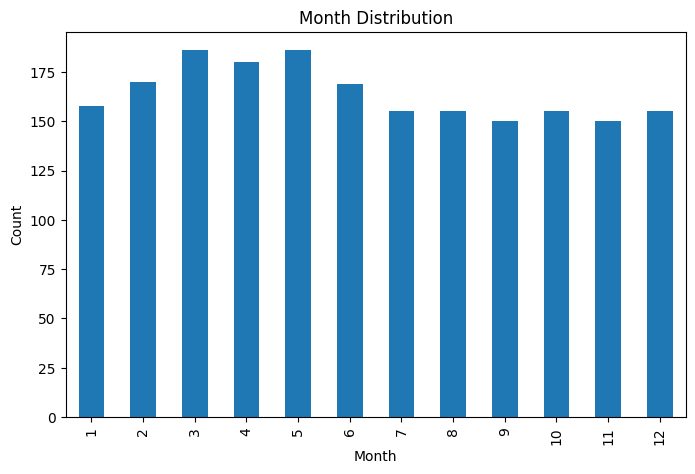

In [19]:
calendar['month'].value_counts().sort_index().plot(kind='bar',figsize=(8,5))

plt.title("Month Distribution")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

<h2 style="color:yellow">Weekday Distribution</h2>

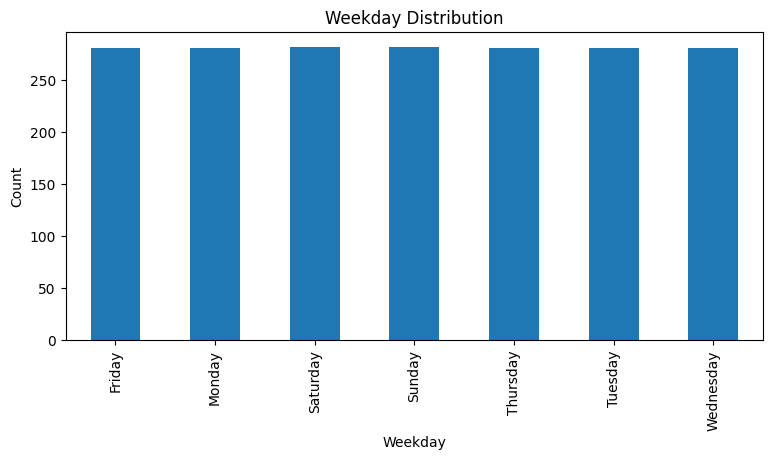

In [20]:
calendar['weekday'].value_counts().sort_index().plot(kind='bar',figsize=(9,4))

plt.title("Weekday Distribution")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.show()

<h2 style="color:yellow">Event Type</h2>

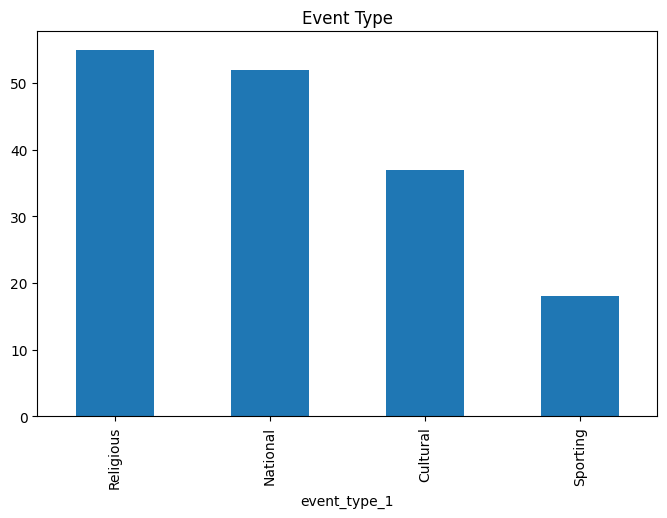

In [21]:
calendar['event_type_1'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title("Event Type")
plt.show()

<h2 style="color:yellow">Price Distribution</h2>
Prize Vs Frequency

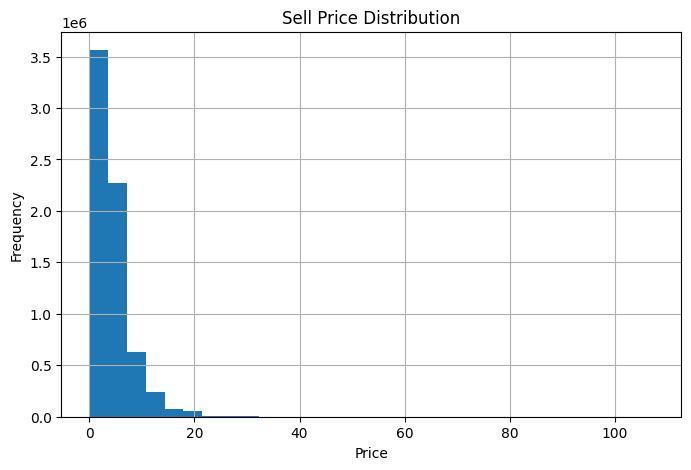

In [22]:
prices['sell_price'].hist(figsize=(8,5), bins=30)

plt.title("Sell Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [23]:
##Lowest Price
prices.sort_values("sell_price",ascending=False).head(10)

,store_id,item_id,wm_yr_wk,sell_price
6485947,WI_3,HOUSEHOLD_2_406,11319,107.32
6485945,WI_3,HOUSEHOLD_2_406,11317,107.32
6485946,WI_3,HOUSEHOLD_2_406,11318,107.32
5805276,WI_2,HOUSEHOLD_2_406,11242,61.46
5805279,WI_2,HOUSEHOLD_2_406,11245,61.46
5805278,WI_2,HOUSEHOLD_2_406,11244,61.46
5805277,WI_2,HOUSEHOLD_2_406,11243,61.46
5805283,WI_2,HOUSEHOLD_2_406,11249,61.46
5805280,WI_2,HOUSEHOLD_2_406,11246,61.46
5805281,WI_2,HOUSEHOLD_2_406,11247,61.46


In [24]:
##Lowest Price
prices.sort_values("sell_price").head(10)

,store_id,item_id,wm_yr_wk,sell_price
6282349,WI_3,HOUSEHOLD_1_036,11444,0.01
5316537,WI_1,FOODS_3_122,11425,0.01
6282348,WI_3,HOUSEHOLD_1_036,11443,0.01
6282347,WI_3,HOUSEHOLD_1_036,11442,0.01
1394086,CA_3,HOBBIES_1_261,11333,0.01
1394087,CA_3,HOBBIES_1_261,11334,0.01
1394085,CA_3,HOBBIES_1_261,11332,0.01
2617306,CA_4,FOODS_3_413,11148,0.01
225727,CA_1,HOUSEHOLD_1_443,11442,0.01
5044267,WI_1,HOUSEHOLD_1_533,11408,0.01


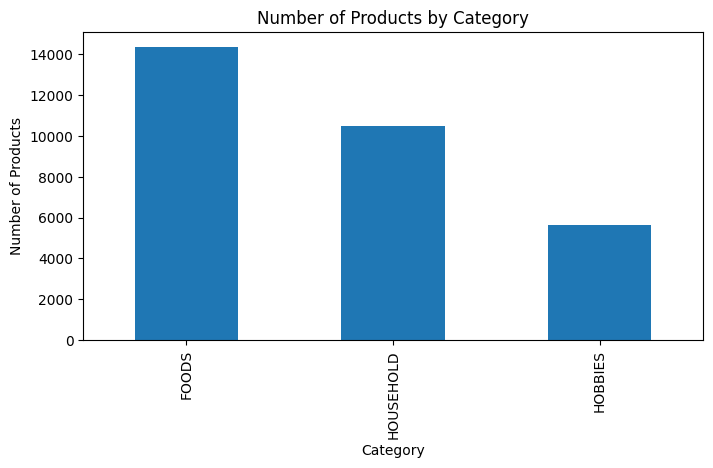

In [25]:
## Total Products in each Category
sales['cat_id'].value_counts().plot(kind='bar', figsize=(8,4))

plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.show()

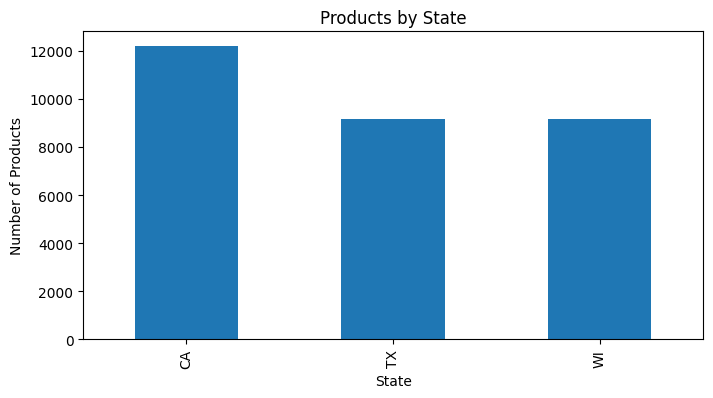

In [26]:
##Total Products by state 
sales['state_id'].value_counts().plot(kind='bar',figsize=(8,4))

plt.title("Products by State")
plt.xlabel("State")
plt.ylabel("Number of Products")
plt.show()

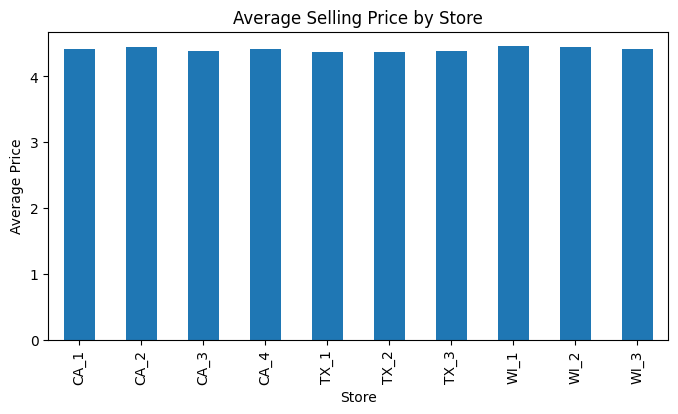

In [27]:
##Average Selling Price by Store
avg_price = prices.groupby('store_id')['sell_price'].mean()

avg_price.plot(kind='bar',figsize=(8,4))

plt.title("Average Selling Price by Store")
plt.xlabel("Store")
plt.ylabel("Average Price")
plt.show()

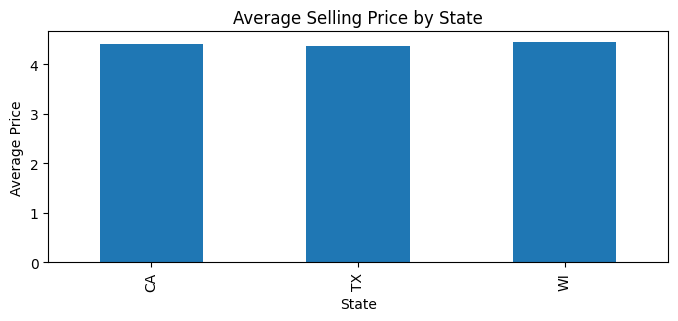

In [28]:
##Average Selling Price by State
prices['state'] = prices['store_id'].str[:2]

avg_state = prices.groupby('state')['sell_price'].mean()
avg_state.plot(kind='bar',figsize=(8,3))

plt.title("Average Selling Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.show()

In [32]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [36]:
print(sales.columns[:10])
print(sales.columns[:-10])

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4'],
      dtype='object')
Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1894', 'd_1895', 'd_1896', 'd_1897', 'd_1898', 'd_1899', 'd_1900',
       'd_1901', 'd_1902', 'd_1903'],
      dtype='object', length=1909)


In [46]:
print(sales.loc[0, 'd_1':'d_10'])

d_1     0
d_2     0
d_3     0
d_4     0
d_5     0
d_6     0
d_7     0
d_8     0
d_9     0
d_10    0
Name: 0, dtype: object


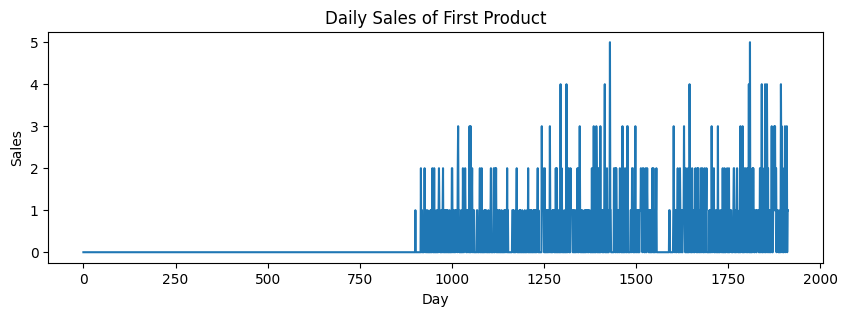

In [48]:
##Sample Daily Sales
sample = sales.loc[0, 'd_1':]

sample = sample.astype(int)

plt.figure(figsize=(10,3))
plt.plot(sample.values)

plt.title("Daily Sales of First Product")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

In [50]:
##Top Selling Products

sales['Total_Sales'] = sales.loc[:, 'd_1':].sum(axis=1)

top_products = sales[['item_id','Total_Sales']].sort_values(
    by='Total_Sales',ascending=False)

top_products.head(10)

,item_id,Total_Sales
8412,FOODS_3_090,250502
18055,FOODS_3_586,192835
21104,FOODS_3_586,150122
8908,FOODS_3_586,134386
2314,FOODS_3_090,127203
29755,FOODS_3_090,121434
17559,FOODS_3_090,119496
20608,FOODS_3_090,114854
17721,FOODS_3_252,114153
15006,FOODS_3_586,112454


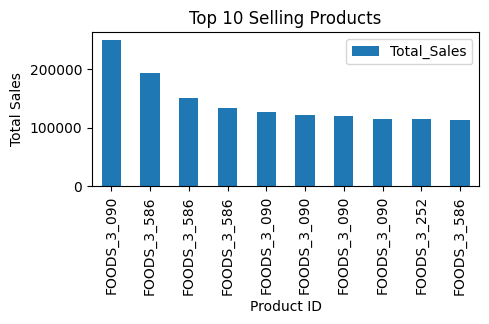

In [53]:
top_products.head(10).plot(x='item_id',y='Total_Sales',kind='bar',figsize=(5,2))

plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Total Sales")
plt.show()